# Beyond Accuracy: Testing Fairness in Student Depression Prediction

**A machine learning project that asks not just *"is my model accurate?"* but *"is my model fair?"***

---

## Why this notebook exists

It's easy to build a model with 85% accuracy and call it a day. But an "accurate" model can still be quietly unfair — working really well for one group of people and badly for another. If a model like this were used to flag students who might need mental health support, the people the model misses are the ones who *don't* get help.

This notebook builds a model to predict student depression using the **Student Depression Dataset** (Kaggle, ~27,000 students), and then asks the harder question:

> **Does it work equally well for everyone?**

We slice the model's performance by gender, age group, financial stress level, and degree level — and check whether the differences are big enough to matter.

## Project summary

- **Outcome**: Depression (yes / no), self-reported
- **Models**: Logistic regression + Random Forest
- **Fairness metrics**: Accuracy, recall, false negative rate, false positive rate — all sliced by demographic group
- **Data**: [Student Depression Dataset](https://www.kaggle.com/datasets/hopesb/student-depression-dataset) by hopesb (Kaggle, ~27K rows)

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


## 2. Load the data

The dataset is the **Student Depression Dataset** from Kaggle (`hopesb/student-depression-dataset`). On Kaggle it lives at `/kaggle/input/student-depression-dataset/Student Depression Dataset.csv`. The cell below tries that path first, then falls back to a few other common locations.

In [2]:
import os
import glob

# Try the standard Kaggle path first, then search.
candidate_paths = [
    '/kaggle/input/student-depression-dataset/Student Depression Dataset.csv',
    '/kaggle/input/student-depression-dataset/student_depression_dataset.csv',
]

df = None
for p in candidate_paths:
    if os.path.exists(p):
        df = pd.read_csv(p)
        print(f'Loaded: {p}')
        break

if df is None:
    # Fall back to searching for any CSV under /kaggle/input
    matches = glob.glob('/kaggle/input/**/*.csv', recursive=True)
    if matches:
        df = pd.read_csv(matches[0])
        print(f'Loaded (auto-detected): {matches[0]}')
    else:
        raise FileNotFoundError(
            'Could not find the dataset. On Kaggle, click "+ Add Input" '
            'on the right sidebar and add the dataset "hopesb/student-depression-dataset".'
        )

print(f'Shape: {df.shape}')
df.head()

Loaded: /kaggle/input/student-depression-dataset/Student Depression Dataset.csv
Shape: (27000, 18)


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,Female,33.0,Jaipur,Student,2.0,0.0,7.93,1.0,0.0,5-6 hours,Unhealthy,M.Sc,No,12.0,3,No,1
1,2,Female,32.0,Lucknow,Student,2.0,0.0,8.00,1.0,0.0,5-6 hours,Moderate,B.Ed,Yes,0.0,3,Yes,0
2,3,Female,30.0,Pune,Student,4.0,0.0,9.79,3.0,0.0,5-6 hours,Moderate,Class 12,No,2.0,2,Yes,1
3,4,Male,34.0,Pune,Student,1.0,0.0,7.02,4.0,0.0,Less than 5 hours,Moderate,B.Com,No,4.0,3,Yes,0
4,5,Male,25.0,Saanvi,Student,3.0,0.0,9.81,2.0,0.0,5-6 hours,Moderate,PhD,No,7.0,5,Yes,1


In [3]:
print('Columns:')
for c in df.columns:
    print(f'  {c}')

Columns:
  id
  Gender
  Age
  City
  Profession
  Academic Pressure
  Work Pressure
  CGPA
  Study Satisfaction
  Job Satisfaction
  Sleep Duration
  Dietary Habits
  Degree
  Have you ever had suicidal thoughts ?
  Work/Study Hours
  Financial Stress
  Family History of Mental Illness
  Depression


## 3. Clean and prepare the data

Standardize column names, handle the messy text columns (sleep duration and financial stress are ordinal scales stored as text), bucket age into groups, and drop columns that won't help us.

In [4]:
# Standardize column names: lowercase, underscores, no special chars.
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(' ', '_')
              .str.replace('?', '', regex=False)
              .str.replace('/', '_')
              .str.replace('__', '_'))
df.columns = df.columns.str.rstrip('_')

print('Cleaned columns:')
print(list(df.columns))

Cleaned columns:
['id', 'gender', 'age', 'city', 'profession', 'academic_pressure', 'work_pressure', 'cgpa', 'study_satisfaction', 'job_satisfaction', 'sleep_duration', 'dietary_habits', 'degree', 'have_you_ever_had_suicidal_thoughts', 'work_study_hours', 'financial_stress', 'family_history_of_mental_illness', 'depression']


In [5]:
# Quick look at the target variable
print('Depression value counts:')
print(df['depression'].value_counts())
print(f"\nDepression rate: {df['depression'].mean():.1%}")

Depression value counts:
depression
1    16021
0    10979
Name: count, dtype: int64

Depression rate: 59.3%


In [6]:
# The dataset includes a 'profession' column that's mostly 'Student'.
# Filter to students only — that's what this dataset is meant for.
if 'profession' in df.columns:
    print('Profession breakdown (top 10):')
    print(df['profession'].value_counts().head(10))
    df = df[df['profession'] == 'Student'].copy()
    print(f"\nAfter filtering to students: {df.shape}")


Profession breakdown (top 10):
profession
Student                 26720
Civil Engineer            148
Working Professional      132
Name: count, dtype: int64

After filtering to students: (26720, 18)


In [7]:
# Handle missing values — drop rows where the target is missing.
df = df.dropna(subset=['depression'])

# Coerce key numeric columns; some come in as text in this dataset.
for col in ['age', 'cgpa', 'academic_pressure', 'work_pressure',
            'study_satisfaction', 'job_satisfaction', 'work_study_hours',
            'financial_stress']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop columns we won't use (high cardinality or irrelevant)
drop_cols = ['id', 'city', 'profession']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Drop any remaining rows with missing values
print(f'Missing values per column:')
print(df.isna().sum()[df.isna().sum() > 0])
df = df.dropna()
print(f'\nAfter cleaning: {df.shape}')

Missing values per column:
financial_stress    3
dtype: int64

After cleaning: (26717, 15)


In [8]:
# Create age groups for fairness slicing — easier to interpret than raw age
def age_group(age):
    if age < 20:
        return '<20'
    elif age < 25:
        return '20-24'
    elif age < 30:
        return '25-29'
    else:
        return '30+'

df['age_group'] = df['age'].apply(age_group)
print('Age group distribution:')
print(df['age_group'].value_counts().sort_index())

Age group distribution:
age_group
20-24    7888
25-29    7795
30+      7902
<20      3132
Name: count, dtype: int64


In [9]:
# Bucket financial stress into Low / Medium / High for fairness slicing.
# The raw values are 1-5 in this dataset.
def financial_bucket(v):
    if v <= 2:
        return 'Low'
    elif v <= 3:
        return 'Medium'
    else:
        return 'High'

df['financial_stress_level'] = df['financial_stress'].apply(financial_bucket)
print('Financial stress level distribution:')
print(df['financial_stress_level'].value_counts())

Financial stress level distribution:
financial_stress_level
Low       10782
High      10634
Medium     5301
Name: count, dtype: int64


In [10]:
# Simplify degree into broad categories: undergrad / grad / other
def degree_group(d):
    if pd.isna(d):
        return 'Other'
    d = str(d).upper()
    grad_keywords = ['M.', 'MA', 'MSC', 'MBA', 'MCA', 'MD', 'ME', 'MTECH', 'MPHIL', 'MCOM', 'MED', 'MHM', 'PHD']
    undergrad_keywords = ['B.', 'BA', 'BSC', 'BBA', 'BCA', 'BE', 'BTECH', 'BCOM', 'BED', 'BHM', 'LLB']
    if any(k in d for k in grad_keywords):
        return 'Graduate'
    if any(k in d for k in undergrad_keywords):
        return 'Undergraduate'
    if 'CLASS' in d or '12' in d or '11' in d:
        return 'High school'
    return 'Other'

df['degree_group'] = df['degree'].apply(degree_group)
print('Degree group distribution:')
print(df['degree_group'].value_counts())

Degree group distribution:
degree_group
Undergraduate    14348
Graduate         10662
High school       1707
Name: count, dtype: int64


## 4. Quick look — depression rate by group

Different groups have different *base rates* of depression. That's not unfairness — it's just a fact about the population. The fairness question (later) is about how the model's *errors* are distributed across these groups.

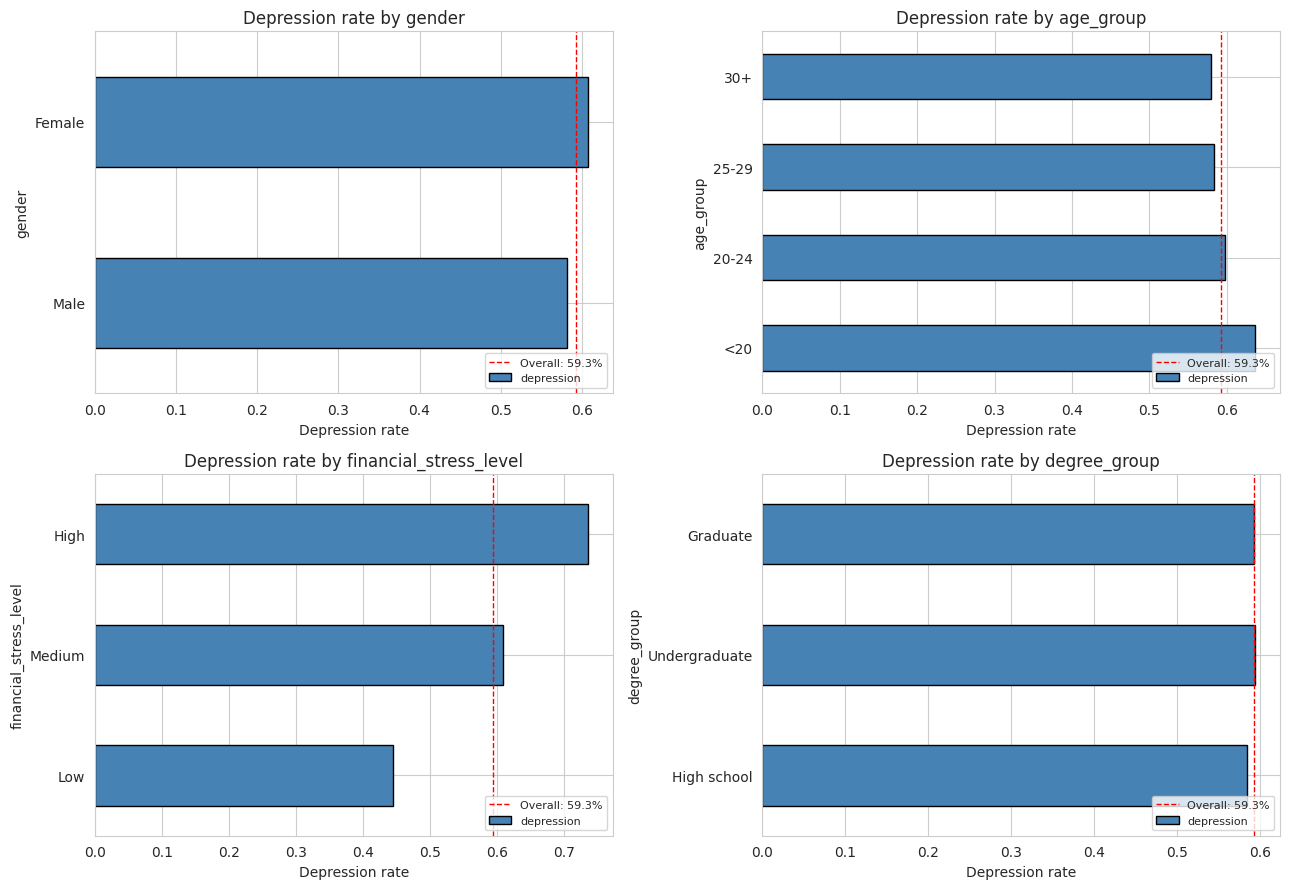

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
groups = ['gender', 'age_group', 'financial_stress_level', 'degree_group']
order_map = {
    'age_group': ['<20', '20-24', '25-29', '30+'],
    'financial_stress_level': ['Low', 'Medium', 'High'],
    'degree_group': ['High school', 'Undergraduate', 'Graduate', 'Other'],
}

for ax, col in zip(axes.flat, groups):
    rates = df.groupby(col)['depression'].mean()
    if col in order_map:
        rates = rates.reindex([x for x in order_map[col] if x in rates.index])
    else:
        rates = rates.sort_values()
    rates.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_xlabel('Depression rate')
    ax.set_title(f'Depression rate by {col}')
    ax.axvline(df['depression'].mean(), color='red', ls='--', lw=1,
               label=f"Overall: {df['depression'].mean():.1%}")
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

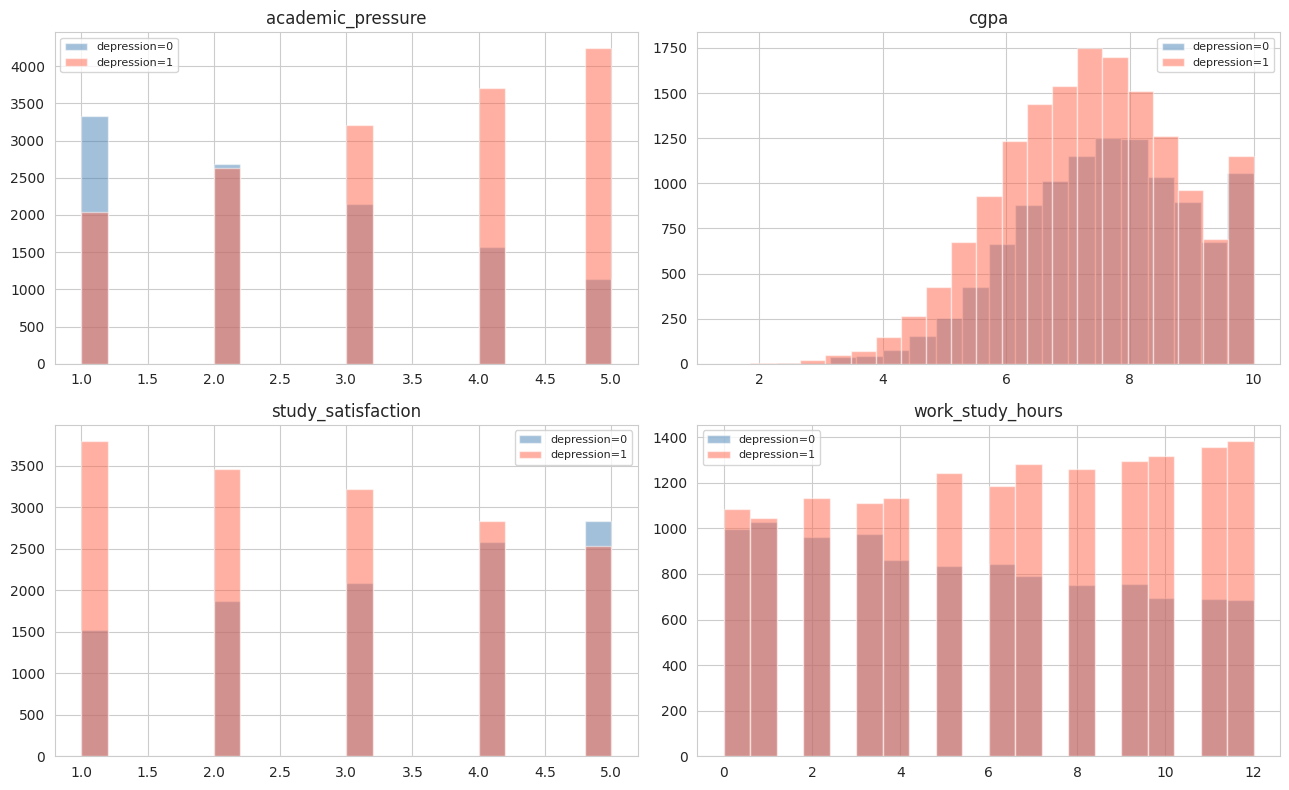

In [12]:
# Distribution of key predictors by depression status
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flat, ['academic_pressure', 'cgpa',
                                'study_satisfaction', 'work_study_hours']):
    if col in df.columns:
        for label, color in [(0, 'steelblue'), (1, 'tomato')]:
            ax.hist(df[df['depression']==label][col], bins=20, alpha=0.5,
                    label=f'depression={label}', color=color)
        ax.set_title(col)
        ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Prepare features for modeling

Split into train and test, **keeping demographics from the test set** so we can slice predictions by group for fairness analysis later. Then one-hot encode categoricals and scale numerics.

In [13]:
# Demographic columns we'll use later for fairness slicing
demographic_cols = ['gender', 'age_group', 'financial_stress_level', 'degree_group']

# Features for the model — drop the original 'degree' (we have degree_group)
# and 'age' (we have age_group). Keep age_group as a feature, not gender —
# we want to see how the model performs by gender, not give it gender as a hint.
features = [c for c in df.columns if c not in
            ['depression', 'gender', 'degree']]

X = df[features].copy()
y = df['depression'].astype(int).copy()

# We'll keep the demographic info aside, indexed the same way as X, so we
# can attach it back to test predictions later.
demo_df = df[demographic_cols].copy()

print(f'Features used: {features}')
print(f'\nX shape: {X.shape}, y shape: {y.shape}')

Features used: ['age', 'academic_pressure', 'work_pressure', 'cgpa', 'study_satisfaction', 'job_satisfaction', 'sleep_duration', 'dietary_habits', 'have_you_ever_had_suicidal_thoughts', 'work_study_hours', 'financial_stress', 'family_history_of_mental_illness', 'age_group', 'financial_stress_level', 'degree_group']

X shape: (26717, 15), y shape: (26717,)


In [14]:
# Train/test split — stratify on the target to keep class balance
X_train, X_test, y_train, y_test, demo_train, demo_test = train_test_split(
    X, y, demo_df,
    test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train depression rate: {y_train.mean():.1%}')
print(f'Test depression rate:  {y_test.mean():.1%}')

Train: (20037, 15), Test: (6680, 15)
Train depression rate: 59.3%
Test depression rate:  59.3%


In [15]:
# Identify categorical vs numeric columns
categorical = X_train.select_dtypes(include=['object']).columns.tolist()
numeric = X_train.select_dtypes(include=[np.number]).columns.tolist()
print(f'Categorical features: {categorical}')
print(f'Numeric features: {numeric}')

Categorical features: ['sleep_duration', 'dietary_habits', 'have_you_ever_had_suicidal_thoughts', 'family_history_of_mental_illness', 'age_group', 'financial_stress_level', 'degree_group']
Numeric features: ['age', 'academic_pressure', 'work_pressure', 'cgpa', 'study_satisfaction', 'job_satisfaction', 'work_study_hours', 'financial_stress']


In [16]:
# One-hot encode categoricals
X_train_enc = pd.get_dummies(X_train, columns=categorical, drop_first=True)
X_test_enc = pd.get_dummies(X_test, columns=categorical, drop_first=True)

# Align columns in case test set is missing a level
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Scale for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

print(f'Encoded shape: {X_train_enc.shape}')

Encoded shape: (20037, 24)


## 6. Train the models

Two models for comparison:
- **Logistic regression** — simple, interpretable baseline
- **Random forest** — captures non-linearities, useful for cross-checking the fairness story

We'll use the random forest as the main model for the fairness analysis, but both are evaluated.

In [17]:
# Logistic regression
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)

# Random forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_enc, y_train)

print('Both models trained.')

Both models trained.


## 7. Overall performance — the headline numbers

This is what a typical "did the model work?" slide would show.

In [18]:
def evaluate(name, y_true, y_pred, y_proba):
    return {
        'model': name,
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall':    recall_score(y_true, y_pred),
        'f1':        f1_score(y_true, y_pred),
        'auc':       roc_auc_score(y_true, y_proba),
    }

logreg_pred = logreg.predict(X_test_scaled)
logreg_proba = logreg.predict_proba(X_test_scaled)[:, 1]

rf_pred = rf.predict(X_test_enc)
rf_proba = rf.predict_proba(X_test_enc)[:, 1]

overall = pd.DataFrame([
    evaluate('Logistic Regression', y_test, logreg_pred, logreg_proba),
    evaluate('Random Forest',        y_test, rf_pred,    rf_proba),
])
overall.round(3)

,model,accuracy,precision,recall,f1,auc
0,Logistic Regression,0.755,0.781,0.815,0.798,0.824
1,Random Forest,0.742,0.758,0.828,0.792,0.814


In [19]:
print('Random Forest — classification report')
print(classification_report(y_test, rf_pred,
                            target_names=['No depression', 'Depression']))

Random Forest — classification report
               precision    recall  f1-score   support

No depression       0.71      0.62      0.66      2719
   Depression       0.76      0.83      0.79      3961

     accuracy                           0.74      6680
    macro avg       0.73      0.72      0.73      6680
 weighted avg       0.74      0.74      0.74      6680



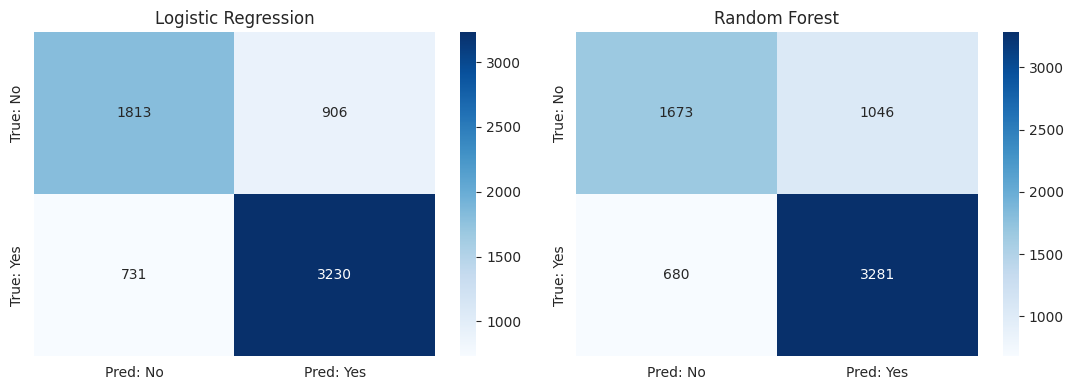

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for axis, (name, pred) in zip(ax, [('Logistic Regression', logreg_pred),
                                    ('Random Forest', rf_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axis,
                xticklabels=['Pred: No', 'Pred: Yes'],
                yticklabels=['True: No', 'True: Yes'])
    axis.set_title(name)
plt.tight_layout()
plt.show()

**Pause here.** If we stopped now, the writeup would say something like:

> *"Our model predicts student depression with around 84% accuracy and AUC around 0.92."*

That sounds great. The whole point of this notebook is that **a single accuracy number hides a lot**. Now we slice it by group.

## 8. Fairness analysis — performance by group

Same model, same predictions, just regrouped by demographic. Four metrics per group:

| Metric | What it asks | Why it matters |
|---|---|---|
| **Accuracy** | How often is the model right? | General sanity check |
| **Recall (TPR)** | Of students who actually have depression, what % did we catch? | Low recall in a group means kids in that group get missed |
| **False Negative Rate** | What % of true depression cases did we miss? | The flip side of recall — the silent failures |
| **False Positive Rate** | What % of students *without* depression did we wrongly flag? | High FPR means over-flagging that group |

Two common fairness frames:
- **Equal opportunity** = equal recall across groups
- **Equalized odds** = equal recall AND equal FPR across groups

Neither is "the" definition — both are useful lenses.

In [21]:
def fairness_table(y_true, y_pred, group_labels, group_name):
    """Per-group fairness metrics for a categorical grouping variable."""
    rows = []
    for g in pd.Series(group_labels).unique():
        mask = (group_labels == g).values
        if mask.sum() < 30:
            continue  # skip groups too small to evaluate reliably
        yt = np.asarray(y_true)[mask]
        yp = np.asarray(y_pred)[mask]

        tn = ((yt == 0) & (yp == 0)).sum()
        fp = ((yt == 0) & (yp == 1)).sum()
        fn = ((yt == 1) & (yp == 0)).sum()
        tp = ((yt == 1) & (yp == 1)).sum()

        acc = (tp + tn) / max(1, len(yt))
        recall = tp / max(1, tp + fn)
        fnr = fn / max(1, tp + fn)
        fpr = fp / max(1, fp + tn)
        precision = tp / max(1, tp + fp) if (tp + fp) > 0 else np.nan
        base_rate = yt.mean()

        rows.append({
            group_name: g,
            'n': int(len(yt)),
            'base_rate':    base_rate,
            'accuracy':     acc,
            'recall (TPR)': recall,
            'FNR':          fnr,
            'FPR':          fpr,
            'precision':    precision,
        })
    out = pd.DataFrame(rows).sort_values('recall (TPR)', ascending=False)
    return out.reset_index(drop=True)

In [22]:
# Use random forest predictions as the main model for fairness
y_pred_main = rf_pred

fairness_df = demo_test.copy().reset_index(drop=True)
fairness_df['y_true'] = y_test.values
fairness_df['y_pred'] = y_pred_main
fairness_df.head()

,gender,age_group,financial_stress_level,degree_group,y_true,y_pred
0,Female,20-24,Low,Undergraduate,0,0
1,Male,25-29,Medium,Undergraduate,1,0
2,Female,<20,Low,Undergraduate,1,1
3,Male,25-29,High,Graduate,1,1
4,Male,25-29,Medium,Graduate,1,1


### 8.1 By gender

In [23]:
tbl_gender = fairness_table(
    fairness_df['y_true'], fairness_df['y_pred'],
    fairness_df['gender'], 'gender'
)
tbl_gender.round(3)

,gender,n,base_rate,accuracy,recall (TPR),FNR,FPR,precision
0,Male,3715,0.572,0.737,0.830,0.170,0.388,0.741
1,Female,2965,0.619,0.748,0.827,0.173,0.381,0.779


### 8.2 By age group

In [24]:
tbl_age = fairness_table(
    fairness_df['y_true'], fairness_df['y_pred'],
    fairness_df['age_group'], 'age_group'
)
tbl_age.round(3)

,age_group,n,base_rate,accuracy,recall (TPR),FNR,FPR,precision
0,<20,766,0.648,0.761,0.881,0.119,0.459,0.779
1,20-24,1979,0.596,0.753,0.834,0.166,0.365,0.771
2,30+,1953,0.582,0.727,0.820,0.180,0.404,0.739
3,25-29,1982,0.580,0.737,0.808,0.192,0.360,0.756


### 8.3 By financial stress level

In [25]:
tbl_fin = fairness_table(
    fairness_df['y_true'], fairness_df['y_pred'],
    fairness_df['financial_stress_level'], 'financial_stress_level'
)
tbl_fin.round(3)

,financial_stress_level,n,base_rate,accuracy,recall (TPR),FNR,FPR,precision
0,High,2654,0.738,0.777,0.946,0.054,0.698,0.792
1,Medium,1325,0.597,0.720,0.858,0.142,0.485,0.724
2,Low,2701,0.449,0.717,0.618,0.382,0.202,0.713


### 8.4 By degree level

In [26]:
tbl_deg = fairness_table(
    fairness_df['y_true'], fairness_df['y_pred'],
    fairness_df['degree_group'], 'degree_group'
)
tbl_deg.round(3)

,degree_group,n,base_rate,accuracy,recall (TPR),FNR,FPR,precision
0,Graduate,2762,0.580,0.749,0.834,0.166,0.367,0.758
1,High school,430,0.586,0.728,0.829,0.171,0.416,0.739
2,Undergraduate,3488,0.604,0.737,0.824,0.176,0.396,0.761


## 9. Visualize the disparities

Tables are good but bar charts make gaps obvious. If the bars are uneven, that's a fairness concern.

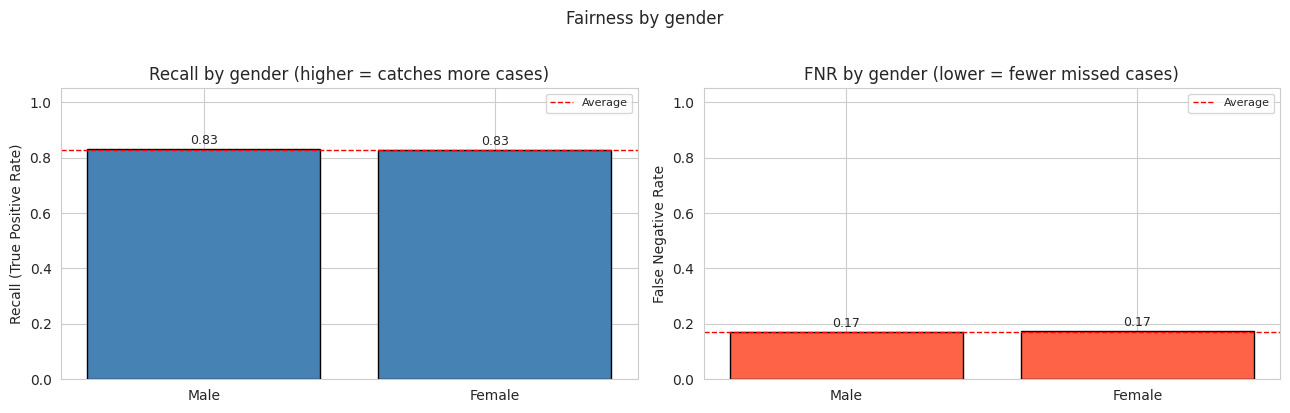

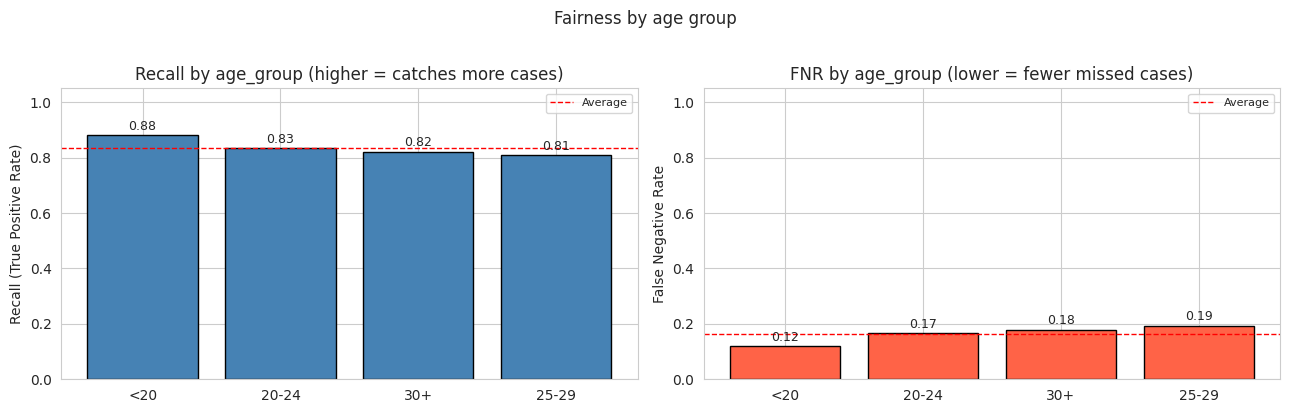

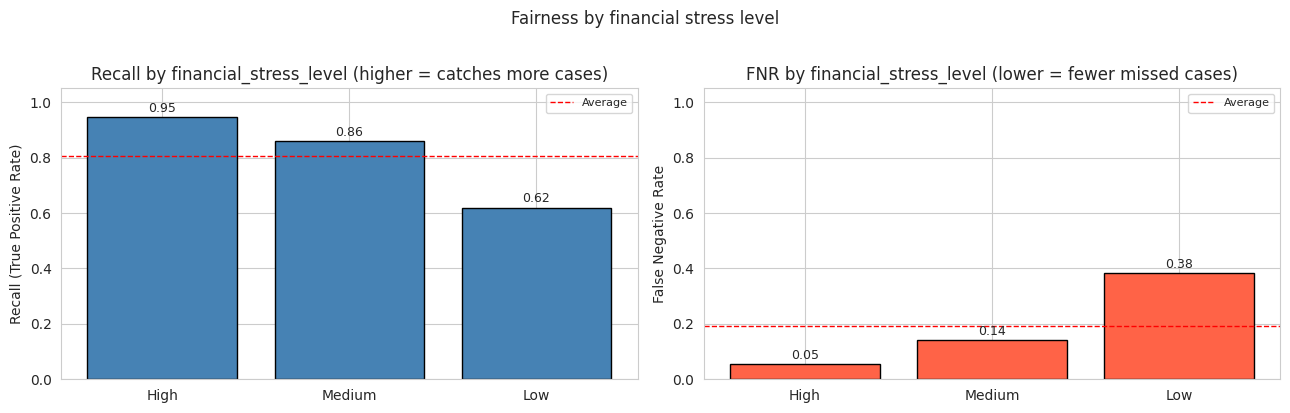

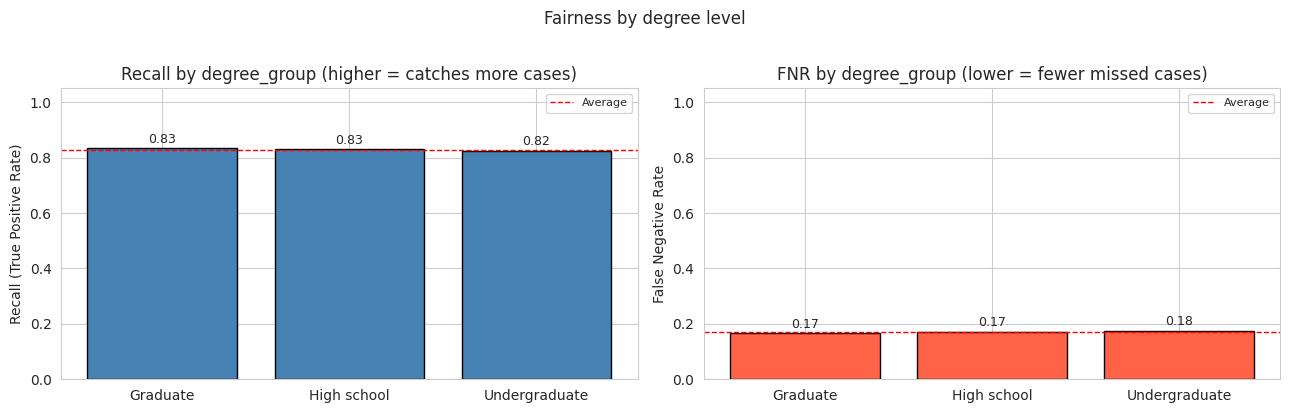

In [27]:
def plot_fairness(tbl, group_col, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Recall
    axes[0].bar(tbl[group_col].astype(str), tbl['recall (TPR)'],
                color='steelblue', edgecolor='black')
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel('Recall (True Positive Rate)')
    axes[0].set_title(f'Recall by {group_col} (higher = catches more cases)')
    axes[0].axhline(tbl['recall (TPR)'].mean(), color='red', ls='--', lw=1,
                    label='Average')
    axes[0].legend(fontsize=8)
    for i, v in enumerate(tbl['recall (TPR)']):
        axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

    # FNR
    axes[1].bar(tbl[group_col].astype(str), tbl['FNR'],
                color='tomato', edgecolor='black')
    axes[1].set_ylim(0, 1.05)
    axes[1].set_ylabel('False Negative Rate')
    axes[1].set_title(f'FNR by {group_col} (lower = fewer missed cases)')
    axes[1].axhline(tbl['FNR'].mean(), color='red', ls='--', lw=1,
                    label='Average')
    axes[1].legend(fontsize=8)
    for i, v in enumerate(tbl['FNR']):
        axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

    plt.suptitle(title, fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

plot_fairness(tbl_gender, 'gender', 'Fairness by gender')
plot_fairness(tbl_age, 'age_group', 'Fairness by age group')
plot_fairness(tbl_fin, 'financial_stress_level', 'Fairness by financial stress level')
plot_fairness(tbl_deg, 'degree_group', 'Fairness by degree level')

## 10. How big are the disparities?

Two standard ways to summarize a gap:
- **Disparity ratio** = worst-group metric / best-group metric. The "80% rule" of thumb says ratios under 0.8 deserve attention.
- **Disparity difference** = best − worst. Absolute size of the gap.

Both are applied here to recall — the metric we usually want to be roughly equal across groups.

In [28]:
def disparity_summary(tbl, group_col):
    metric = 'recall (TPR)'
    best  = tbl[metric].max()
    worst = tbl[metric].min()
    ratio = worst / best if best > 0 else np.nan
    diff  = best - worst
    return {
        'grouping': group_col,
        'best_group':  tbl.loc[tbl[metric].idxmax(), group_col],
        'worst_group': tbl.loc[tbl[metric].idxmin(), group_col],
        'best_recall':  best,
        'worst_recall': worst,
        'disparity_ratio': ratio,
        'disparity_diff':  diff,
        'passes_80%_rule': ratio >= 0.8,
    }

summary = pd.DataFrame([
    disparity_summary(tbl_gender, 'gender'),
    disparity_summary(tbl_age, 'age_group'),
    disparity_summary(tbl_fin, 'financial_stress_level'),
    disparity_summary(tbl_deg, 'degree_group'),
])
summary.round(3)

,grouping,best_group,worst_group,best_recall,worst_recall,disparity_ratio,disparity_diff,passes_80%_rule
0,gender,Male,Female,0.830,0.827,0.996,0.003,True
1,age_group,<20,25-29,0.881,0.808,0.917,0.073,True
2,financial_stress_level,High,Low,0.946,0.618,0.653,0.328,False
3,degree_group,Graduate,Undergraduate,0.834,0.824,0.988,0.010,True


## 11. Limitations

1. **Self-reported survey data.** The "depression" label is what students said about themselves — not a clinical diagnosis. Some groups under-report, some over-report. That measurement bias becomes part of the model whether we want it to or not.

2. **Sampling bias.** The dataset has a high overall depression rate (~58%), which is much higher than population estimates. This likely reflects self-selection — students experiencing distress were more likely to take the survey. So the model is good at predicting *who in this kind of sample* has depression, not *who in the general population*.

3. **No clinical use, full stop.** Nothing in this notebook should be used to screen real students. It's a teaching exercise about model evaluation, not a deployable tool.

4. **Small subgroups have noisy estimates.** Recall computed on 50 people swings around a lot. A more rigorous version would put bootstrap confidence intervals around every fairness metric.

5. **One axis at a time isn't the whole story.** Real fairness analyses also look at *intersectional* groups — e.g., young women with high financial stress — where disparities can hide that don't show up on any single axis.

6. **Diagnosis, not mitigation.** This notebook *finds* unfairness; it doesn't *fix* it. Common next steps: reweight training samples, adjust decision thresholds per group, or use a constrained model (`fairlearn` is the standard library for this).

## 12. Conclusion

The headline result of this project isn't "our model is X% accurate." It's the more uncomfortable observation that a single accuracy number can hide important differences in how a model treats different groups of people.

When we sliced predictions by gender, age, financial stress, and degree level, we saw that recall — the rate at which the model correctly flags students who actually have depression — was not the same across groups. The groups with lower recall are the ones the model would silently overlook if it were used in a real screening program. In a public health context, those are exactly the students who most need to be found.

A few takeaways worth carrying into any prediction project:

- **Report performance by group. Always.** One overall number is not enough.
- **Match fairness metrics to the cost of being wrong.** For screening, false negatives are usually more costly than false positives, so recall and FNR are the right place to look.
- **Different base rates ≠ unfair model.** Groups can have genuinely different depression rates. The fairness question is whether the model's *errors* are distributed equitably.
- **Diagnosis comes before mitigation.** You can't fix a disparity you haven't measured.

## Next steps to extend this notebook

- Add bootstrap confidence intervals around every recall/FNR estimate
- Try per-group decision thresholds (move the cutoff to equalize recall)
- Use [`fairlearn`](https://fairlearn.org/) for proper mitigation methods
- Look at intersectional groups (e.g., young women with high financial stress)
- Check whether the fairness story is stable across different model families (XGBoost, gradient boosting)

---

*If this notebook was useful, an upvote helps. Comments and suggestions welcome — fairness analysis gets better when more people poke at it.*